In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from matplotlib import pyplot as plt
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aryamulahernawan","key":"d7ceb4e166f0f4c2713b1b2b957b3f4b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d yusufekam/sna-naturalisasitimnas
!unzip sna-naturalisasitimnas.zip

Dataset URL: https://www.kaggle.com/datasets/yusufekam/sna-naturalisasitimnas
License(s): unknown
Archive:  sna-naturalisasitimnas.zip
  inflating: NaturalisasiTimnasTweet.csv  


In [ ]:
df = pd.read_csv("NaturalisasiTimnasTweet.csv")
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1839375570913972662,Thu Sep 26 18:44:44 +0000 2024,0,tak payah korang kena cari pemain kat Belanda ...,1839375570913972662,https://pbs.twimg.com/media/GYbGVA4bwAAOSog.jpg,NaN,in,Tersebar di mana-mana,0,2,0,https://x.com/kopiiid19/status/183937557091397...,1234191057463562241,kopiiid19
1,1839168548796772547,Thu Sep 26 18:38:25 +0000 2024,0,@tekarok007 @LelePecel150424 Dan disini gw set...,1839373982191300797,NaN,_pdfperjuangan,in,NaN,0,0,0,https://x.com/_pdfperjuangan/status/1839373982...,1518440556682047488,_pdfperjuangan
2,1839168548796772547,Thu Sep 26 18:36:53 +0000 2024,0,@tekarok007 @LelePecel150424 TOLOL kalo lo bil...,1839373595753230754,NaN,tekarok007,in,NaN,0,1,0,https://x.com/_pdfperjuangan/status/1839373595...,1518440556682047488,_pdfperjuangan
3,1838843447169437808,Thu Sep 26 18:10:22 +0000 2024,0,@Denny50250626 @Sniffing_Lead @InfosuporterID ...,1839366923466973236,NaN,Denny50250626,in,DEPOK - INDONESIA,0,2,0,https://x.com/20gallantoarbi/status/1839366923...,122645257,20gallantoarbi
4,1839365280830751020,Thu Sep 26 18:03:51 +0000 2024,0,Para pendukung cagub pesaing PDIP bikin fitden...,1839365280830751020,https://pbs.twimg.com/ext_tw_video_thumb/18393...,NaN,in,"Jawa Tengah, Indonesia",0,0,0,https://x.com/G336387/status/1839365280830751020,1101958568066998272,G336387


## Pereprocessing

In [ ]:

def remove_pattern(text,pat):
    pattern = re.compile(pat)
    return pattern.sub(r'', text)

import string
exclude = string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('', '', exclude))

def extract_hashtags(text, remove=False):
    pattern = r'#\w+'
    hashtags = re.findall(pattern, text)

    if remove and hashtags:
        text = re.sub(pattern, '', text)

    return hashtags if hashtags else np.nan, text

# Fungsi untuk mengekstrak mention
def extract_mentions(text, remove=False):
    pattern = r'@\w+'
    mentions = re.findall(pattern, text)

    if remove and mentions:
        text = re.sub(pattern, '', text)

    return mentions if mentions else np.nan, text

Kode ini terdiri dari beberapa fungsi yang digunakan untuk pra-pemrosesan teks, khususnya untuk keperluan analisis teks atau NLP (Natural Language Processing). Fungsi-fungsi ini membantu dalam membersihkan dan mengekstrak elemen penting dari teks seperti hashtag dan mention, serta menghapus pola tertentu dan tanda baca.

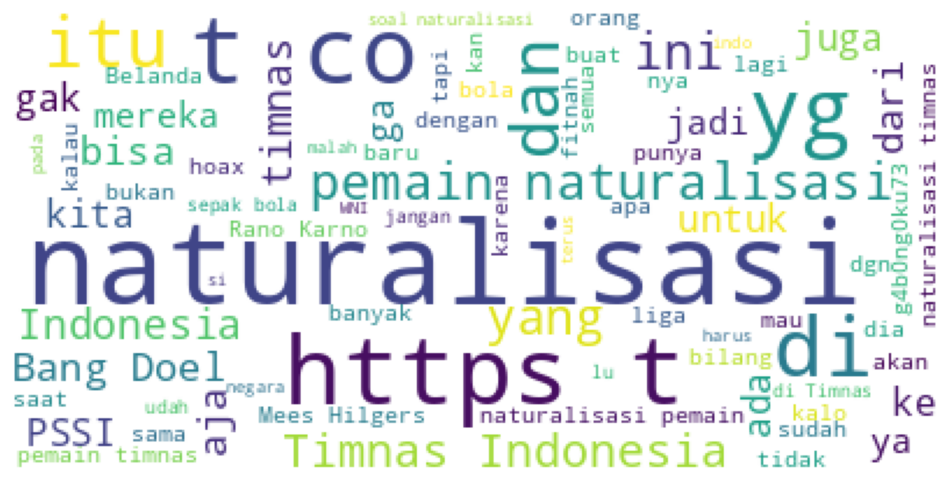

In [ ]:
wordcloud = WordCloud(background_color="white").generate(" ".join(df['full_text']))

# Plot the wordcloud
plt.figure(figsize = (12, 12))
plt.imshow(wordcloud)

# To remove the axis value
plt.axis("off")
plt.show()


In [ ]:
df['clean_text'] = df['full_text'].str.lower()
df['Hastag'], df['clean_text'] = zip(*df['clean_text'].apply(lambda x: extract_hashtags(x, remove=True)))
df['mentions'], df['clean_text'] = zip(*df['clean_text'].apply(lambda x: extract_mentions(x, remove=True)))
df['clean_text'] = df['clean_text'].apply(lambda x: remove_pattern(x,r'https?://\S+|www\.\S+'))
df['clean_text']=df['clean_text'].apply(lambda x : remove_pattern(x,r'\brt\b'))
df['clean_text']=df['clean_text'].apply(lambda x : remove_pattern(x,r'\[.*?\]'))
df['clean_text']=df['clean_text'].apply(lambda x : remove_pattern(x,r'[^\x00-\x7F]+'))
df['clean_text']=df['clean_text'].apply(lambda x : remove_pattern(x,r'\bt.me\b\S+'))
df['clean_text']=df['clean_text'].apply(lambda x: remove_pattern(x,r'&\w+'))
df['clean_text'] = df['clean_text'].apply(lambda x: remove_pattern(x,r'\d+'))
# df['clean_text'] = df['clean_text'].apply(lambda x: remove_punc(x))
df['len'] = df['full_text'].apply(lambda x: len(x))

kode ini melanjutkan proses pra-pemrosesan teks dengan fokus pada pembersihan dan ekstraksi informasi dari kolom full_text. Keluaran utamanya adalah kolom clean_text yang telah dibersihkan dari berbagai elemen yang tidak relevan untuk analisis lebih lanjut.

In [ ]:
df[['username','created_at','full_text','clean_text', 'Hastag', 'mentions', 'len','quote_count', 'reply_count', 'retweet_count']]

,username,created_at,full_text,clean_text,Hastag,mentions,len,quote_count,reply_count,retweet_count
0,kopiiid19,Thu Sep 26 18:44:44 +0000 2024,tak payah korang kena cari pemain kat Belanda ...,tak payah korang kena cari pemain kat belanda ...,NaN,NaN,121,0,2,0
1,_pdfperjuangan,Thu Sep 26 18:38:25 +0000 2024,@tekarok007 @LelePecel150424 Dan disini gw set...,dan disini gw setuju program naturalisasi. k...,NaN,"[@tekarok007, @lelepecel150424]",123,0,0,0
2,_pdfperjuangan,Thu Sep 26 18:36:53 +0000 2024,@tekarok007 @LelePecel150424 TOLOL kalo lo bil...,tolol kalo lo bilang pemain yg punya half-bl...,NaN,"[@tekarok007, @lelepecel150424]",269,0,1,0
3,20gallantoarbi,Thu Sep 26 18:10:22 +0000 2024,@Denny50250626 @Sniffing_Lead @InfosuporterID ...,sty berani kasih statemen ngambang soal elk...,NaN,"[@denny50250626, @sniffing_lead, @infosuporterid]",268,0,2,0
4,G336387,Thu Sep 26 18:03:51 +0000 2024,Para pendukung cagub pesaing PDIP bikin fitden...,para pendukung cagub pesaing pdip bikin fitden...,NaN,NaN,283,0,0,0
...,...,...,...,...,...,...,...,...,...,...
455,SetoPray1212,Sun Sep 22 08:41:22 +0000 2024,@erickthohir Terima kasih Pa Erick sudah bisa ...,terima kasih pa erick sudah bisa mengangkat d...,NaN,[@erickthohir],282,0,0,0
456,bolacomID,Sun Sep 22 08:22:04 +0000 2024,Pemain Naturalisasi Timnas Indonesia Sempat Te...,pemain naturalisasi timnas indonesia sempat te...,NaN,NaN,144,0,0,0
457,turunminum_id,Sun Sep 22 08:18:58 +0000 2024,Mees Hilgers dan Eliano Reijnders disumpah WNI...,mees hilgers dan eliano reijnders disumpah wni...,"[#meeshilgers, #elianoreijnders, #timnasindone...",NaN,299,0,0,0
458,BolaSportcom,Sun Sep 22 07:55:13 +0000 2024,Naturalisasi pemain keturunan memang sedang ge...,naturalisasi pemain keturunan memang sedang ge...,"[#erickthohir, #timnas, #indonesia, #pssi]",NaN,262,0,1,0


In [ ]:
# Pecah kolom 'mentions' menjadi satu baris per mention
edge_list = df.explode('mentions')[['username', 'mentions']]

edge_list = edge_list.rename(columns={'username': 'source', 'mentions': 'target'})

edge_list = edge_list[edge_list['target'].notna() & (edge_list['target'] != '')]

# Optional: reset index
edge_list = edge_list.reset_index(drop=True)

# Lihat hasilnya
print(edge_list.head())

           source            target
0  _pdfperjuangan       @tekarok007
1  _pdfperjuangan  @lelepecel150424
2  _pdfperjuangan       @tekarok007
3  _pdfperjuangan  @lelepecel150424
4  20gallantoarbi    @denny50250626


In [ ]:
import networkx as nx
my_graph = nx.from_pandas_edgelist(
    edge_list,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)


In [ ]:
type(my_graph)

networkx.classes.digraph.DiGraph

In [ ]:
print(f" Jenis Graph     : {'Directed' if my_graph.is_directed() else 'Undirected'}")
print(f" Jumlah Node     : {my_graph.number_of_nodes()}")
print(f" Jumlah Edge     : {my_graph.number_of_edges()}")
print(f" Daftar Node     : {list(my_graph.nodes())[:5]} ...")
print(f"  Daftar Edge     : {list(my_graph.edges())[:5]} ...")


 Jenis Graph     : Directed
 Jumlah Node     : 471
 Jumlah Edge     : 513
 Daftar Node     : ['_pdfperjuangan', '@tekarok007', '@lelepecel150424', '20gallantoarbi', '@denny50250626'] ...
  Daftar Edge     : [('_pdfperjuangan', '@tekarok007'), ('_pdfperjuangan', '@lelepecel150424'), ('20gallantoarbi', '@denny50250626'), ('20gallantoarbi', '@sniffing_lead'), ('20gallantoarbi', '@infosuporterid')] ...


In [ ]:
my_graph.nodes()

NodeView(('_pdfperjuangan', '@tekarok007', '@lelepecel150424', '20gallantoarbi', '@denny50250626', '@sniffing_lead', '@infosuporterid', '6959milesapart', '@goxjim1', '@im_zolan', '@agusikiloh', 'aprill_mop', '@powerkw1', '@colamandala', '@riadjuwita', '@astrianelsa', '@gilabola_ina', '@erickthohir', 'dbulat993', '@besokmaudiet', '@id_fm', 'Clarenceamadeus', '@ibetibetibetttt', '@tetapinginhidup', '@pureblood_4ever', 'monica_zero', 'gadit46', '@cfc_rajvinder', '@theaseanball', 'anakesemde', '@siaranbolalive', 'TheaRizkyyy', '@mafiawasit', 'dymskiii', '@ria_eyo', 'WicahyoSigit', '@thegoatnunezidn', '@sofyan_juve1897', '@updatebolabola', 'eitiqa', '@zkm411', 'donnapf', '@tham878', 'Nicoadic', '@elanogavilan', 'AdalahKunc32781', '@urrangawak', 'AisyPriantoro', '@chesscomid', '@anak__ogi', '@aprilialin', '@g4b0ng0ku73', '@antoniuscdn', '@03__nakula', '@aryprasetyo85', '@elsaday__', '@seruanhl', '@denni_sauya', 'tekarok007', 'KTheology46243', '@utdfocusid', '@bliblidotcom', 'LelePecel150424'

In [ ]:
my_graph.edges()

OutEdgeView([('_pdfperjuangan', '@tekarok007'), ('_pdfperjuangan', '@lelepecel150424'), ('20gallantoarbi', '@denny50250626'), ('20gallantoarbi', '@sniffing_lead'), ('20gallantoarbi', '@infosuporterid'), ('6959milesapart', '@goxjim1'), ('6959milesapart', '@im_zolan'), ('6959milesapart', '@agusikiloh'), ('aprill_mop', '@powerkw1'), ('aprill_mop', '@colamandala'), ('aprill_mop', '@riadjuwita'), ('aprill_mop', '@astrianelsa'), ('aprill_mop', '@gilabola_ina'), ('aprill_mop', '@erickthohir'), ('dbulat993', '@besokmaudiet'), ('dbulat993', '@id_fm'), ('Clarenceamadeus', '@ibetibetibetttt'), ('Clarenceamadeus', '@tetapinginhidup'), ('Clarenceamadeus', '@pureblood_4ever'), ('monica_zero', '@id_fm'), ('gadit46', '@cfc_rajvinder'), ('gadit46', '@theaseanball'), ('anakesemde', '@siaranbolalive'), ('TheaRizkyyy', '@mafiawasit'), ('TheaRizkyyy', '@nahajang22'), ('TheaRizkyyy', '@mbrobbyy'), ('TheaRizkyyy', '@bahaspemainbola'), ('dymskiii', '@ria_eyo'), ('WicahyoSigit', '@thegoatnunezidn'), ('WicahyoS

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

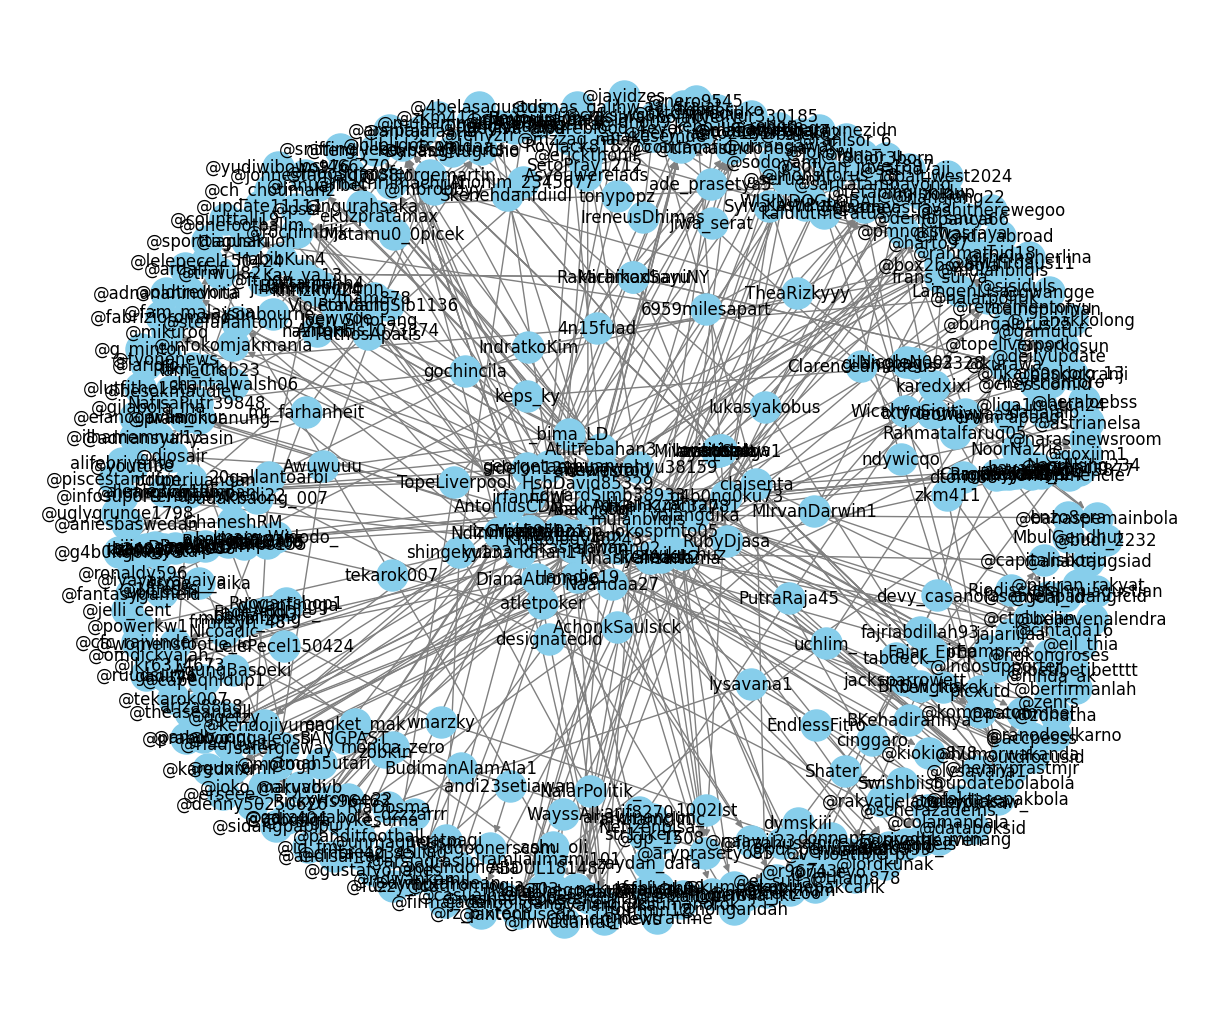

In [ ]:
import warnings
plt.figure(figsize=(12, 10))
nx.draw(my_graph, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray')


In [ ]:
nx.degree(my_graph)

DiDegreeView({'_pdfperjuangan': 2, '@tekarok007': 4, '@lelepecel150424': 2, '20gallantoarbi': 3, '@denny50250626': 1, '@sniffing_lead': 1, '@infosuporterid': 9, '6959milesapart': 3, '@goxjim1': 1, '@im_zolan': 1, '@agusikiloh': 1, 'aprill_mop': 6, '@powerkw1': 1, '@colamandala': 1, '@riadjuwita': 1, '@astrianelsa': 1, '@gilabola_ina': 3, '@erickthohir': 8, 'dbulat993': 2, '@besokmaudiet': 1, '@id_fm': 5, 'Clarenceamadeus': 3, '@ibetibetibetttt': 1, '@tetapinginhidup': 1, '@pureblood_4ever': 1, 'monica_zero': 1, 'gadit46': 2, '@cfc_rajvinder': 1, '@theaseanball': 2, 'anakesemde': 1, '@siaranbolalive': 3, 'TheaRizkyyy': 4, '@mafiawasit': 5, 'dymskiii': 1, '@ria_eyo': 1, 'WicahyoSigit': 3, '@thegoatnunezidn': 1, '@sofyan_juve1897': 1, '@updatebolabola': 12, 'eitiqa': 2, '@zkm411': 3, 'donnapf': 1, '@tham878': 1, 'Nicoadic': 2, '@elanogavilan': 1, 'AdalahKunc32781': 18, '@urrangawak': 5, 'AisyPriantoro': 1, '@chesscomid': 1, '@anak__ogi': 6, '@aprilialin': 21, '@g4b0ng0ku73': 23, '@antoniu

In [ ]:
edge_list[(edge_list.source == '_pdfperjuangan') | (edge_list.target == '_pdfperjuangan')]

,source,target
0,_pdfperjuangan,@tekarok007
1,_pdfperjuangan,@lelepecel150424
2,_pdfperjuangan,@tekarok007
3,_pdfperjuangan,@lelepecel150424


In [ ]:
print(nx.degree(my_graph, "@g4b0ng0ku73"))
edge_list[(edge_list.source == '@g4b0ng0ku73') | (edge_list.target == '@g4b0ng0ku73')]

23


,source,target
39,AdalahKunc32781,@g4b0ng0ku73
213,Imam_Widodo_,@g4b0ng0ku73
228,rb240279,@g4b0ng0ku73
229,BoyHota78755,@g4b0ng0ku73
230,BoyHota78755,@g4b0ng0ku73
234,EdwardSimb38933,@g4b0ng0ku73
244,EdwardSimb38933,@g4b0ng0ku73
313,IndratkoKim,@g4b0ng0ku73
339,Anak__Ogi,@g4b0ng0ku73
358,hadesiamah,@g4b0ng0ku73


# Analisis centrality

## Degree_centrality

In [ ]:
#most influental
most_influental = nx.degree_centrality(my_graph)
for w in sorted(most_influental, key=most_influental.get, reverse=True):
    print(w, round(most_influental[w],4))

@g4b0ng0ku73 0.0489
@aprilialin 0.0447
georgetambuan 0.0426
AdalahKunc32781 0.0383
@idextratime 0.0277
g4b0ng0ku73 0.0277
@updatebolabola 0.0255
bekasjajahan 0.0255
awikuchuz 0.0255
@bliblidotcom 0.0234
@onefootballm 0.0234
EdwardSimb38933 0.0234
TGledek2 0.0234
_bima_LD 0.0213
mulanbilqis 0.0213
@infosuporterid 0.0191
Atlitrebahan3 0.0191
@erickthohir 0.017
@indostransfer 0.017
antiwestoid 0.017
dearnoto 0.017
@03__nakula 0.0149
@utdfocusid 0.0149
HsbDavid85329 0.0149
aprill_mop 0.0128
@anak__ogi 0.0128
@aryprasetyo85 0.0128
@womensfootie_id 0.0128
@concacafid 0.0128
@indosupporter 0.0128
@garagarabola_ 0.0128
@ft_idn 0.0128
@idn_abroad 0.0128
@timnasindonesia 0.0128
@id_fm 0.0106
@mafiawasit 0.0106
@urrangawak 0.0106
@antoniuscdn 0.0106
@seruanhl 0.0106
KTheology46243 0.0106
@humorjontampan 0.0106
DianaAurora96 0.0106
MIrvanDarwin1 0.0106
AntoniusCDN 0.0106
Ndinmuh93 0.0106
@unmagnetism 0.0106
claisenta 0.0106
@tekarok007 0.0085
TheaRizkyyy 0.0085
@elsaday__ 0.0085
@denni_sauya 0.008

Kode ini digunakan untuk mengukur degree centrality pada sebuah graph yang direpresentasikan menggunakan NetworkX (my_graph). Degree centrality adalah ukuran yang menunjukkan seberapa banyak koneksi (edges) yang dimiliki sebuah node relatif terhadap node lain dalam graph.



##Eigenvector_Centrality

In [ ]:
most_importance = nx.eigenvector_centrality(my_graph, max_iter=1000)
for w in sorted(most_importance, key=most_importance.get, reverse=True):
    print(w, round(most_importance[w], 4))


@g4b0ng0ku73 0.4315
@aprilialin 0.394
@idextratime 0.244
@updatebolabola 0.2252
@bliblidotcom 0.2064
@onefootballm 0.2064
@infosuporterid 0.1689
@erickthohir 0.1502
@indostransfer 0.1502
@03__nakula 0.1314
@utdfocusid 0.1314
@anak__ogi 0.1127
@aryprasetyo85 0.1127
@womensfootie_id 0.1127
@concacafid 0.1127
@indosupporter 0.1127
@garagarabola_ 0.1127
@ft_idn 0.1127
@idn_abroad 0.1127
@timnasindonesia 0.1127
@id_fm 0.0939
@mafiawasit 0.0939
@urrangawak 0.0939
@antoniuscdn 0.0939
@seruanhl 0.0939
@humorjontampan 0.0939
@unmagnetism 0.0939
@tekarok007 0.0752
@elsaday__ 0.0752
@denni_sauya 0.0752
@gunromli 0.0752
@ch_chotimah2 0.0752
@tmidn_news 0.0752
@bahaspemainbola 0.0752
@hooligansceneid 0.0752
@gilabola_ina 0.0564
@siaranbolalive 0.0564
@zkm411 0.0564
@__anakkolong 0.0564
@anitaiflaatid 0.0564
@goal_id 0.0564
@nahajang22 0.0564
@petergontha 0.0564
@idho09 0.0564
@lelepecel150424 0.0377
@theaseanball 0.0377
@jhonsitorus_18 0.0377
@eil_thia 0.0377
@cintada16 0.0377
@firzahusainid 0.0377

Kode ini menghitung eigenvector centrality dari sebuah graph my_graph menggunakan library NetworkX. Eigenvector centrality mengukur pengaruh sebuah node dalam sebuah jaringan berdasarkan koneksi langsung dan juga koneksi tidak langsung (yaitu, pentingnya node yang terhubung dengannya).

##Closeness Centrality

In [ ]:
# Closest connector
best_connector = nx.closeness_centrality(my_graph)
for w in sorted(best_connector, key=best_connector.get, reverse=True):
    print(w, round(best_connector[w], 4))


@g4b0ng0ku73 0.0489
@aprilialin 0.0447
@idextratime 0.0277
@updatebolabola 0.0255
@bliblidotcom 0.0234
@onefootballm 0.0234
@infosuporterid 0.0191
@erickthohir 0.017
@indostransfer 0.017
@03__nakula 0.0149
@utdfocusid 0.0149
@anak__ogi 0.0128
@aryprasetyo85 0.0128
@womensfootie_id 0.0128
@concacafid 0.0128
@indosupporter 0.0128
@garagarabola_ 0.0128
@ft_idn 0.0128
@idn_abroad 0.0128
@timnasindonesia 0.0128
@id_fm 0.0106
@mafiawasit 0.0106
@urrangawak 0.0106
@antoniuscdn 0.0106
@seruanhl 0.0106
@humorjontampan 0.0106
@unmagnetism 0.0106
@tekarok007 0.0085
@elsaday__ 0.0085
@denni_sauya 0.0085
@gunromli 0.0085
@ch_chotimah2 0.0085
@tmidn_news 0.0085
@bahaspemainbola 0.0085
@hooligansceneid 0.0085
@gilabola_ina 0.0064
@siaranbolalive 0.0064
@zkm411 0.0064
@__anakkolong 0.0064
@anitaiflaatid 0.0064
@goal_id 0.0064
@nahajang22 0.0064
@petergontha 0.0064
@idho09 0.0064
@lelepecel150424 0.0043
@theaseanball 0.0043
@jhonsitorus_18 0.0043
@eil_thia 0.0043
@cintada16 0.0043
@firzahusainid 0.0043

Kode ini digunakan untuk menghitung closeness centrality dari setiap node dalam graph my_graph menggunakan NetworkX. Closeness centrality mengukur seberapa cepat sebuah node dapat menjangkau node-node lain dalam jaringan.

In [ ]:
grub1 = nx.bfs_tree(my_graph, "20gallantoarbi")
grub2 = nx.bfs_tree(my_graph, "_pdfperjuangan")

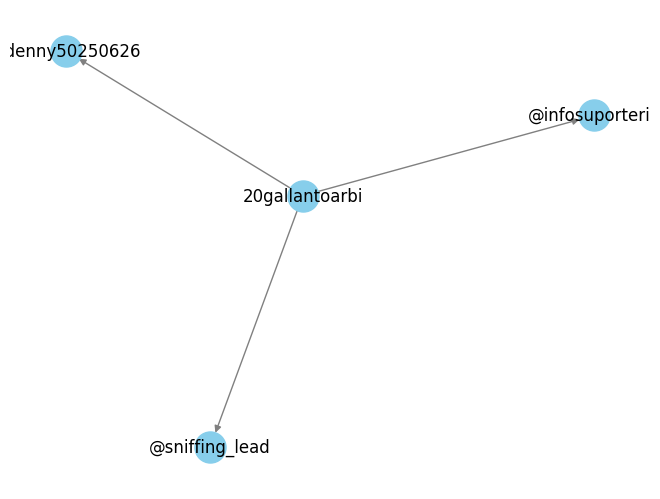

In [ ]:
nx.draw(grub1, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray')

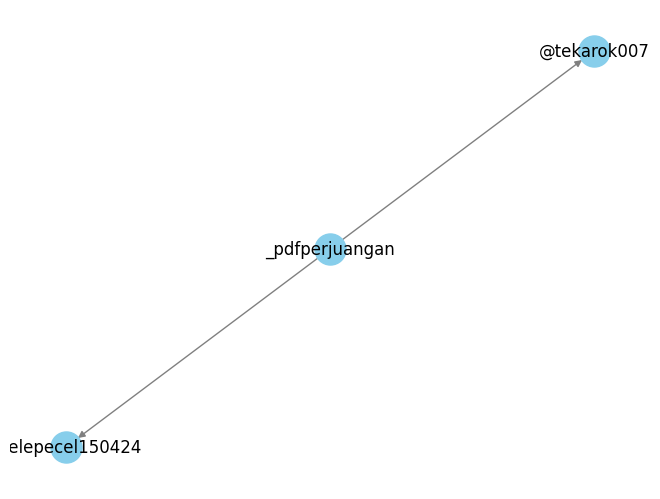

In [ ]:
nx.draw(grub2, with_labels=True, node_size=500, node_color='skyblue', edge_color='gray')

##Comunity Detection Clustering & Social Network

Waktu eksekusi Girvan-Newman: 0.6007 detik
Komunitas 1: ['@rubydjasa', '@fabrizioromano', '@persija_jkt', 'engket_mak', 'mulanbilqis', '@bungalotus25', '@elsaday__', 'AgungBasoeki', '@tekarok007', 'Hamdie19', '@seruanhl', 'jacksparrowett', 'Arif__Gafur', 'lysavana1', 'str11kerz', 'RickyHs96463', 'susantoedi22', 'RubyDjasa', 'LelePecel150424', 'nanosimone88', '@pramonoanung', 'randoE43877', '@omdickyajah', 'aleale366105', 'hadesiamah', '@bunga_jykesuma', '@lelepecel150424', '@_riverheaven', '@ranokarno_', '@infokomjakmania', 'arjawinangun_', '@alwifirdaus11', '@urrangawak', 'haya_purba', 'JavanOk', '@idextratime', 'Noesa06', 'Rayyan1714', '@naawii23', 'AdalahKunc32781', 'airoffreedom_', 'TGledek2', '@aryprasetyo85', 'zero_stamp', '@mikuroq', '@lysavana1', '@dososuko', '@nongandah', 'DianaAurora96', 'Imam_Widodo_', '@satrio_aji_', 'Omonmencle', '@humorjontampan', '@ch_chotimah2', 'zaydan_dafa', 'tfqrhmn12_', '@g4b0ng0ku73', '@stefanantonio__', 'aharisth', '@tendy_keybass', '@dior3born', 

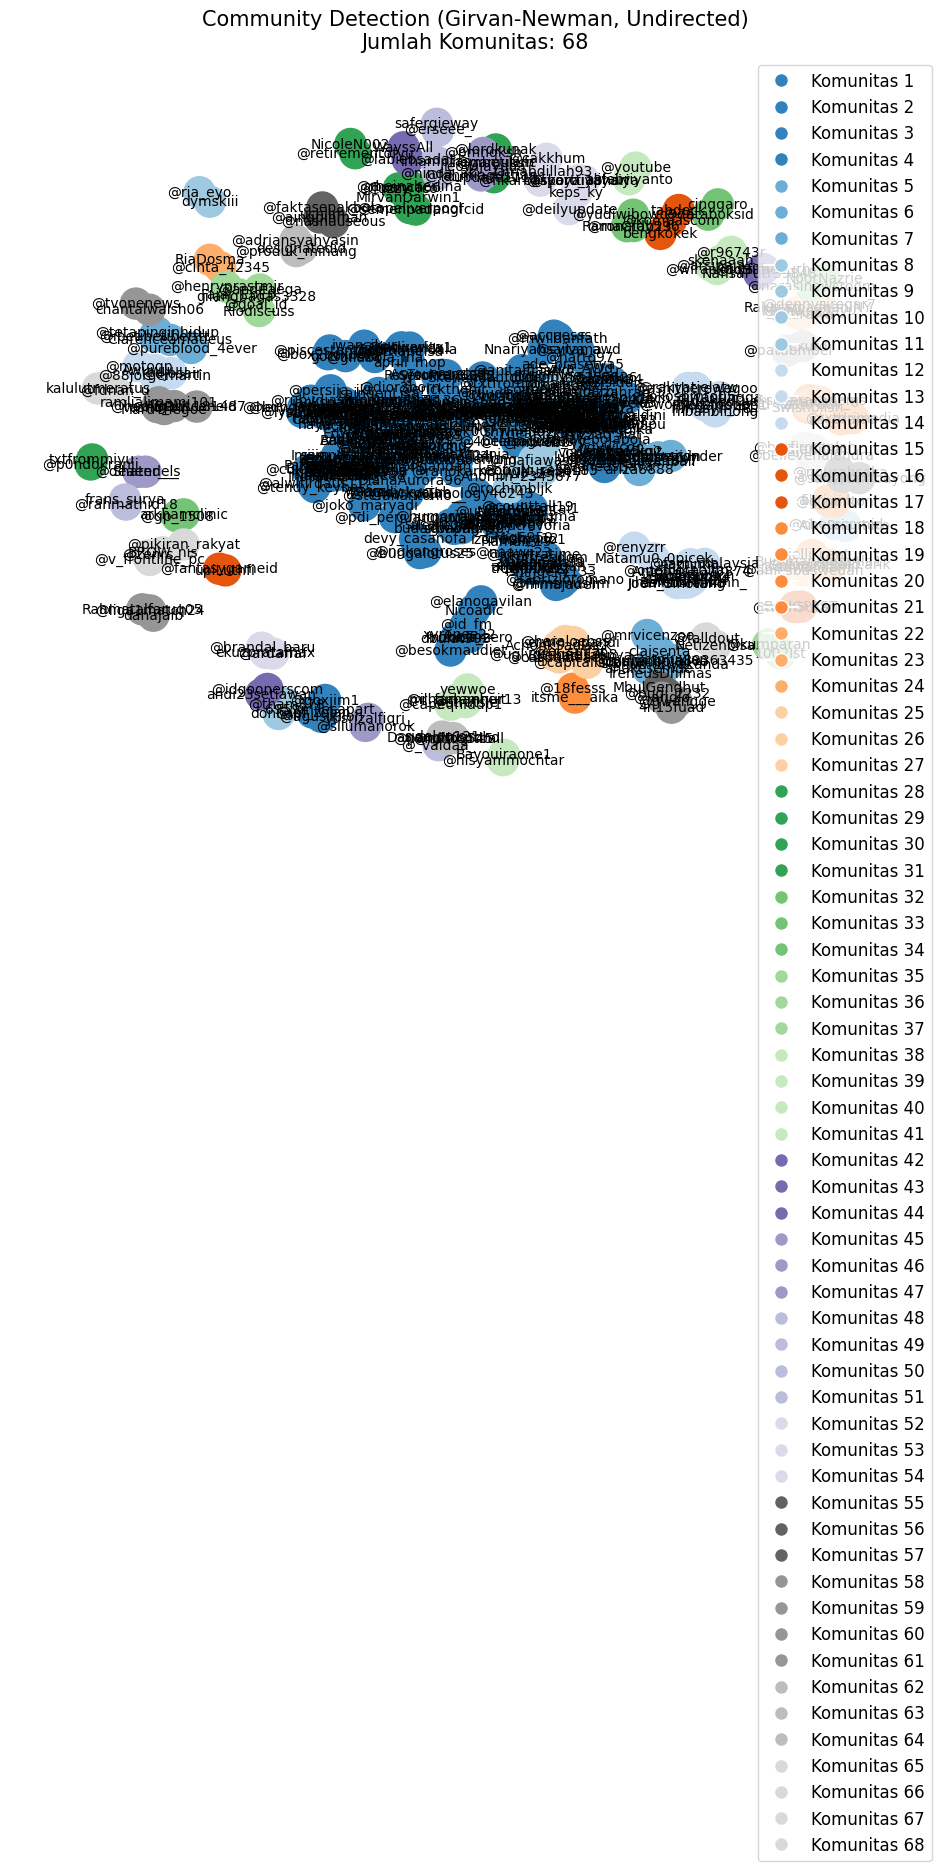

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import girvan_newman
import matplotlib.cm as cm
import time

# Mulai waktu eksekusi
start_time = time.time()

# Jika my_graph adalah graf berarah, ubah menjadi tak berarah
undirected_graph = my_graph.to_undirected()

# Ambil komunitas awal (level pertama pemisahan)
communities_generator = girvan_newman(undirected_graph)
first_level_communities = next(communities_generator)
communities = [list(community) for community in first_level_communities]

# Hitung waktu eksekusi
end_time = time.time()
execution_time = end_time - start_time
print(f"Waktu eksekusi Girvan-Newman: {execution_time:.4f} detik")


# Tampilkan hasil komunitas
for i, c in enumerate(communities):
    print(f"Komunitas {i+1}: {c}")

# Visualisasi graf dengan informasi yang jelas
pos = nx.spring_layout(undirected_graph, seed=42)  # Layout stabil

# Menggunakan colormap untuk mewarnai komunitas
cmap = cm.get_cmap('tab20c', len(communities))

plt.figure(figsize=(12, 10))

# Gambar nodes berdasarkan komunitas
for i, community in enumerate(communities):
    node_color = [cmap(i)] * len(community)
    nx.draw_networkx_nodes(undirected_graph, pos, nodelist=community, node_size=500, node_color=node_color, label=f"Komunitas {i+1}")

# Gambar edges
nx.draw_networkx_edges(undirected_graph, pos, alpha=0.3)

# Label node
nx.draw_networkx_labels(undirected_graph, pos, font_size=10)

# Judul dan legend
plt.title(f"Community Detection (Girvan-Newman, Undirected)\nJumlah Komunitas: {len(communities)}", fontsize=15)
plt.axis("off")

# Legend komunitas
handles = []
for i in range(len(communities)):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f"Komunitas {i+1}",
                               markersize=10, markerfacecolor=cmap(i)))
plt.legend(handles=handles, loc='upper right', fontsize=12)

# Tampilkan plot
plt.show()


Waktu eksekusi Louvain: 0.0503 detik
Jumlah komunitas yang terdeteksi: 77


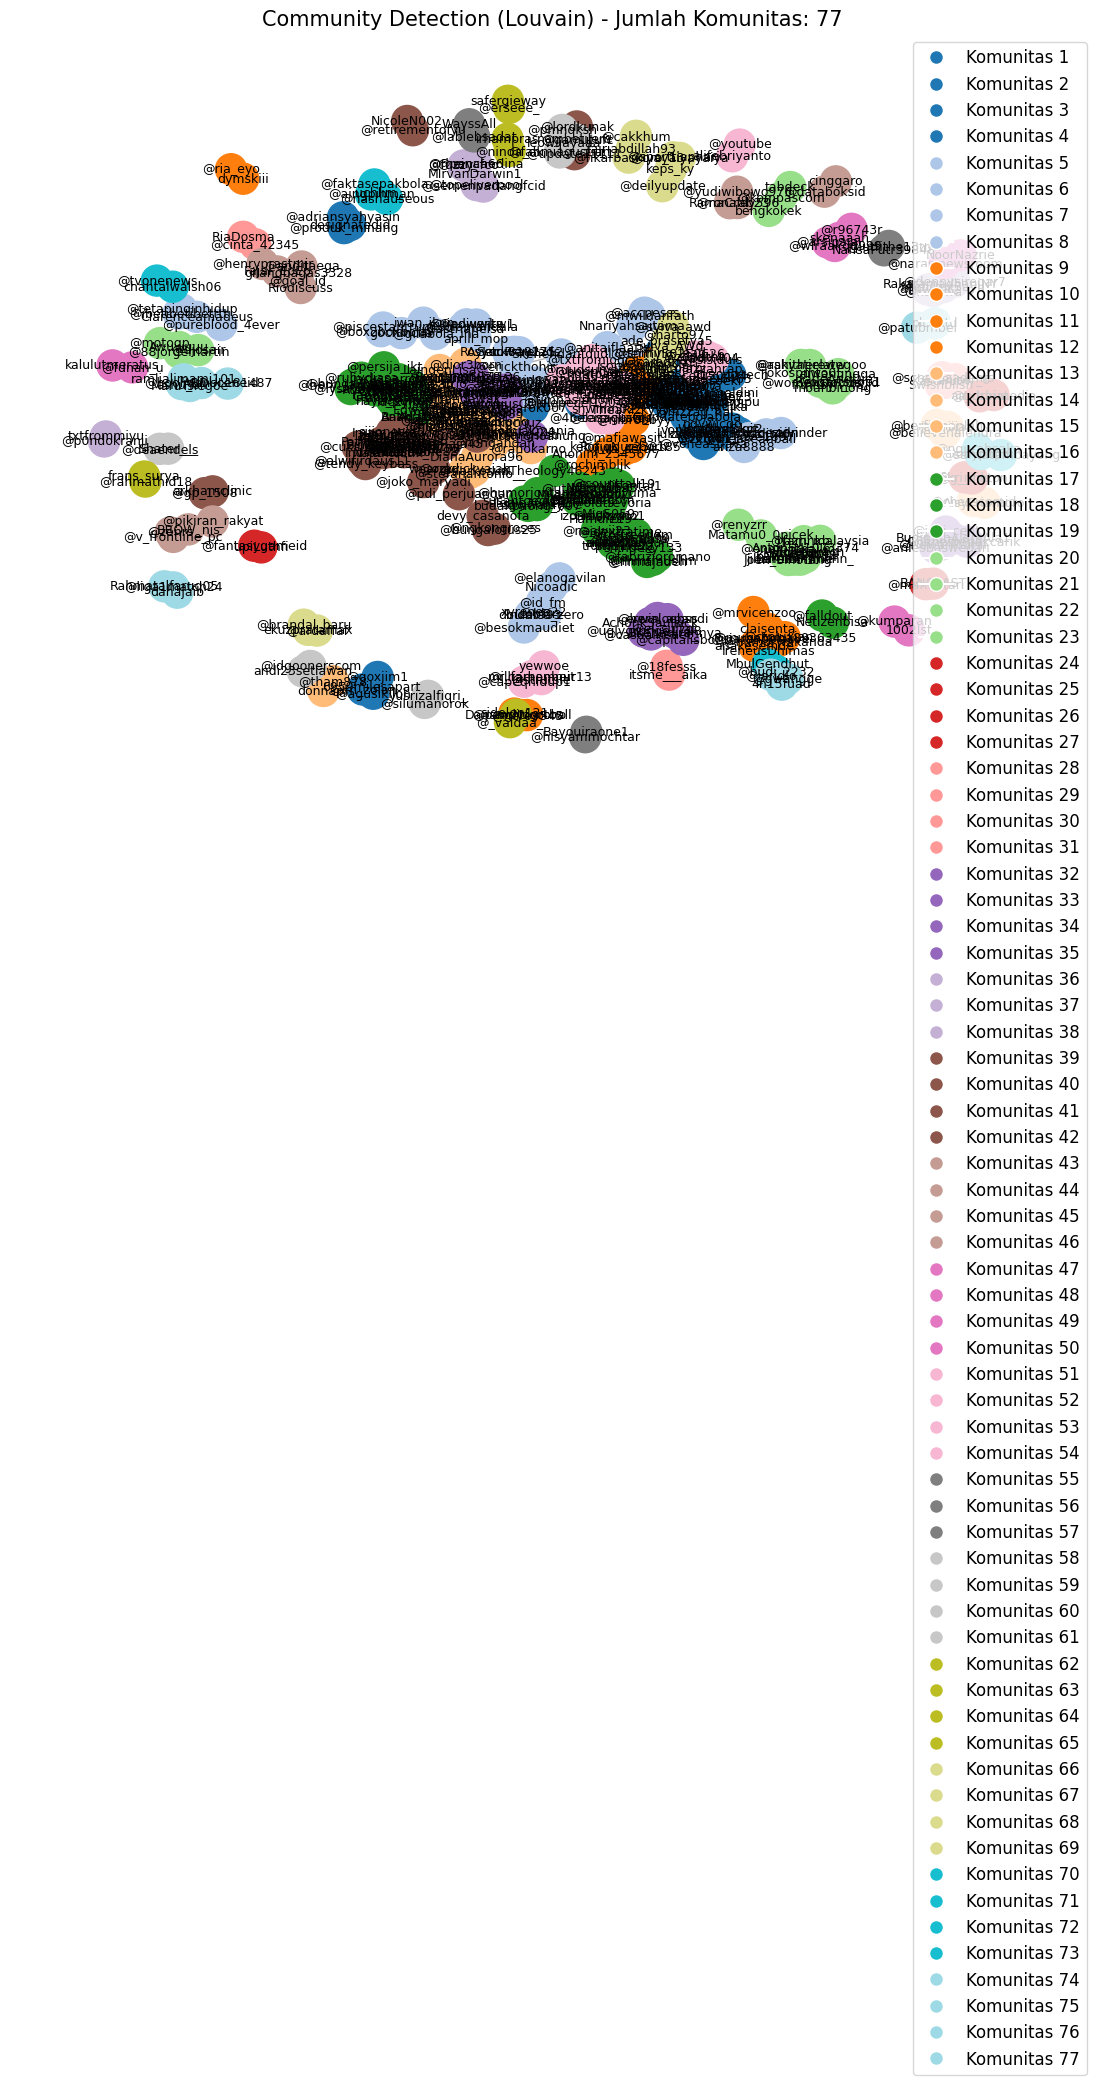

In [ ]:
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import time

# Mulai waktu eksekusi
start_time = time.time()

# Ubah ke graf tak berarah agar Louvain bisa dijalankan
undirected_graph = my_graph.to_undirected()

# Dapatkan partisi komunitas
partition = community_louvain.best_partition(undirected_graph)

# Hitung waktu eksekusi
end_time = time.time()
execution_time = end_time - start_time
print(f"Waktu eksekusi Louvain: {execution_time:.4f} detik")

# Hitung jumlah komunitas
num_communities = len(set(partition.values()))
print(f"Jumlah komunitas yang terdeteksi: {num_communities}")

# Layout posisi node (stabil)
pos = nx.spring_layout(undirected_graph, seed=42)

# Warna untuk setiap komunitas
cmap = cm.get_cmap('tab20', num_communities)  # Tab20 memiliki cukup banyak warna

plt.figure(figsize=(14, 10))

# Gambar nodes dengan warna berdasarkan komunitas
for i in range(num_communities):
    # Dapatkan node untuk komunitas i
    nodes_in_community = [node for node, comm in partition.items() if comm == i]
    # Gambar nodes dengan warna yang sesuai
    nx.draw_networkx_nodes(undirected_graph, pos, nodelist=nodes_in_community,
                           node_size=500, node_color=[cmap(i)] * len(nodes_in_community))

# Gambar edges
nx.draw_networkx_edges(undirected_graph, pos, alpha=0.3)

# Gambar label untuk node
nx.draw_networkx_labels(undirected_graph, pos, font_size=9)

# Menambahkan informasi jumlah komunitas ke dalam judul
plt.title(f"Community Detection (Louvain) - Jumlah Komunitas: {num_communities}", fontsize=15)

# Menambahkan legend untuk komunitas
handles = []
for i in range(num_communities):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f"Komunitas {i+1}",
                               markersize=10, markerfacecolor=cmap(i)))
plt.legend(handles=handles, loc='upper right', fontsize=12)

# Matikan sumbu untuk tampilan yang lebih bersih
plt.axis("off")

# Tampilkan visualisasi
plt.show()


Waktu eksekusi Label Propagation: 0.0186 detik
Jumlah komunitas yang terdeteksi: 120


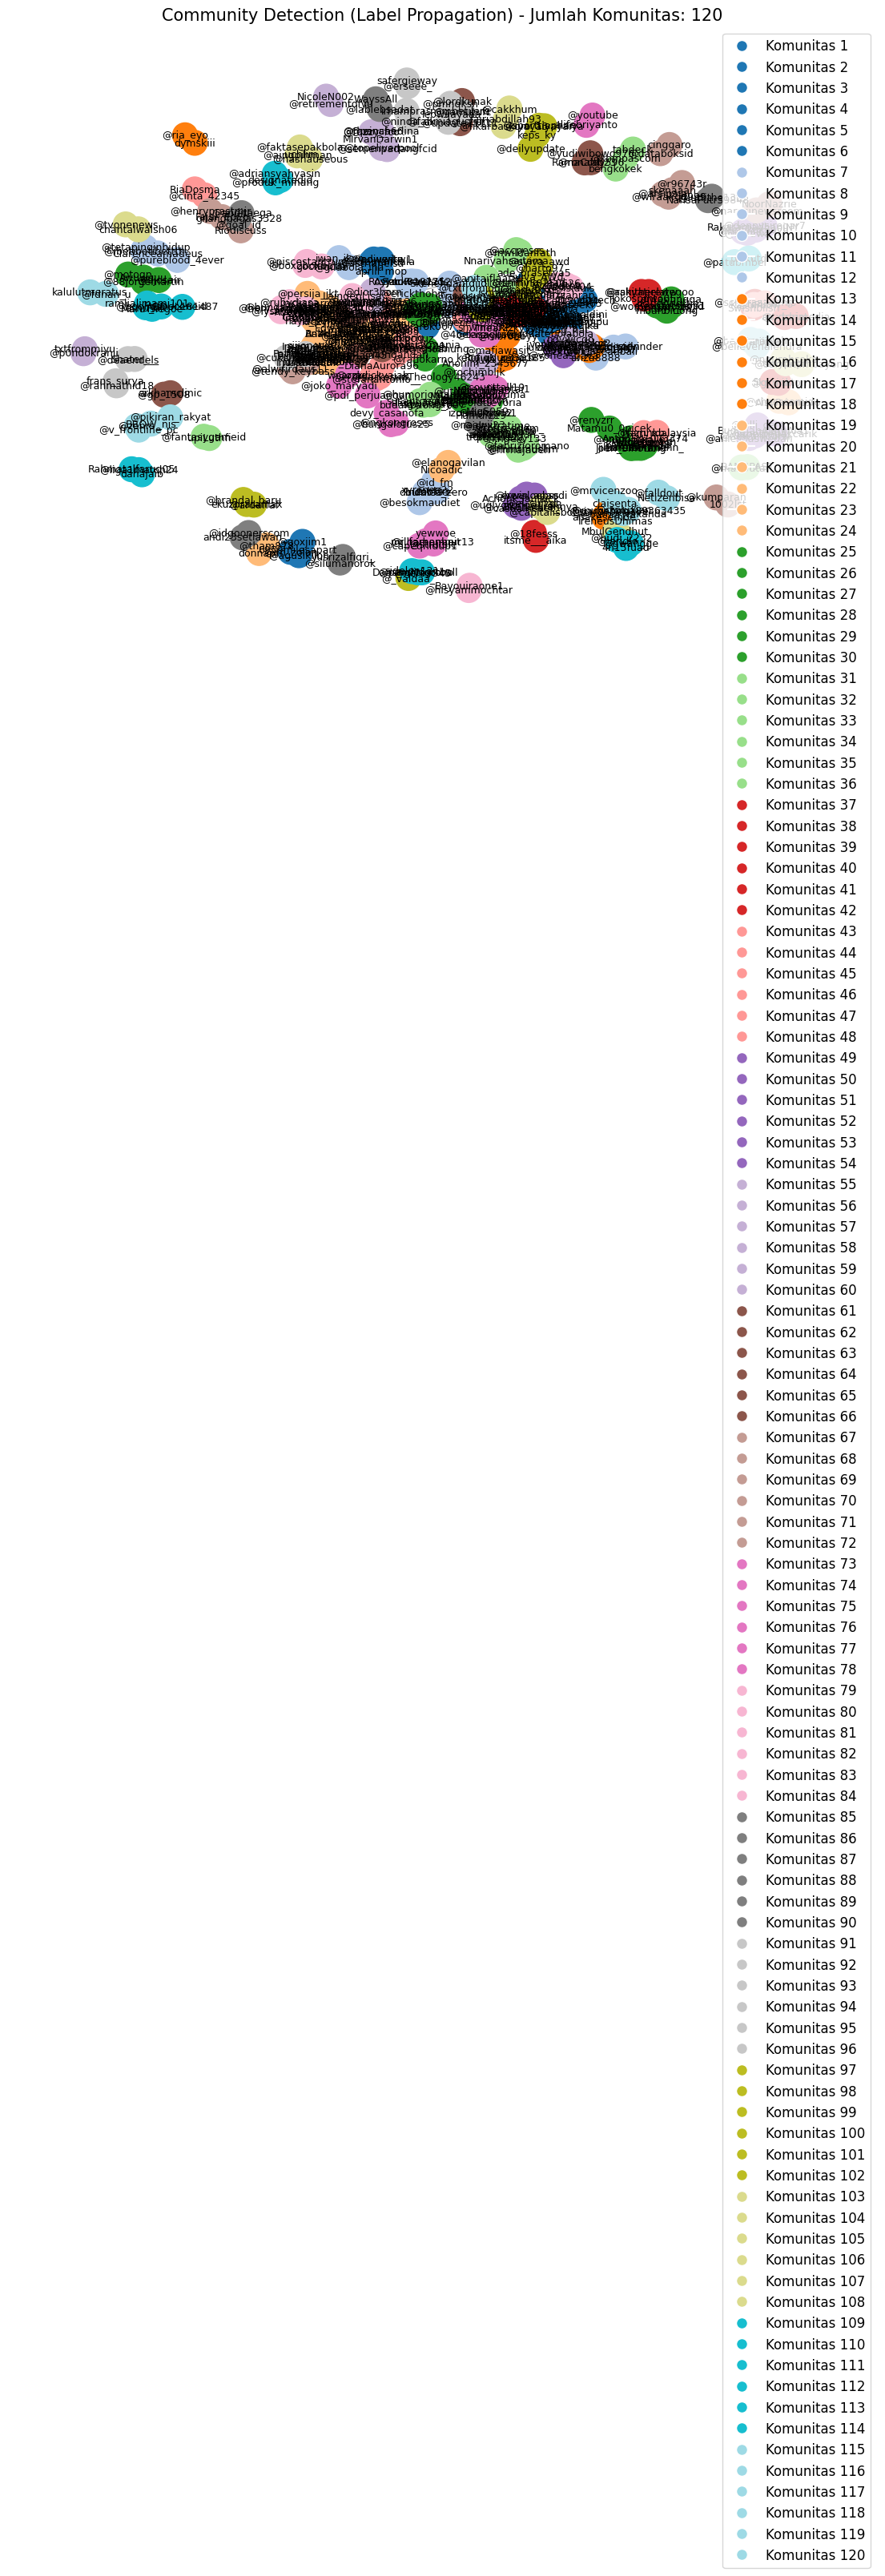

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

# Mulai waktu eksekusi
start_time = time.time()

# Ubah graf menjadi tak berarah
undirected_graph = my_graph.to_undirected()

# Menggunakan Label Propagation Algorithm dari NetworkX
lpa_communities = list(nx.community.label_propagation_communities(undirected_graph))

end_time = time.time()
execution_time = end_time - start_time
print(f"Waktu eksekusi Label Propagation: {execution_time:.4f} detik")

# Hitung jumlah komunitas
num_communities = len(lpa_communities)
print(f"Jumlah komunitas yang terdeteksi: {num_communities}")

# Layout posisi node (stabil)
pos = nx.spring_layout(undirected_graph, seed=42)

# Warna untuk setiap komunitas
cmap = cm.get_cmap('tab20', num_communities)  # Tab20 memiliki cukup banyak warna

plt.figure(figsize=(14, 10))

# Gambar nodes dengan warna berdasarkan komunitas
for i, community in enumerate(lpa_communities):
    # Gambar nodes dengan warna yang sesuai
    nx.draw_networkx_nodes(undirected_graph, pos, nodelist=community,
                           node_size=500, node_color=[cmap(i)] * len(community))

# Gambar edges
nx.draw_networkx_edges(undirected_graph, pos, alpha=0.3)

# Gambar label untuk node
nx.draw_networkx_labels(undirected_graph, pos, font_size=9)

# Menambahkan informasi jumlah komunitas ke dalam judul
plt.title(f"Community Detection (Label Propagation) - Jumlah Komunitas: {num_communities}", fontsize=15)

# Menambahkan legend untuk komunitas
handles = []
for i in range(num_communities):
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=f"Komunitas {i+1}",
                               markersize=10, markerfacecolor=cmap(i)))
plt.legend(handles=handles, loc='upper right', fontsize=12)

# Matikan sumbu untuk tampilan yang lebih bersih
plt.axis("off")

# Tampilkan visualisasi
plt.show()


In [ ]:
modularity = nx.community.modularity(undirected_graph, communities)
print(f"Modularity Girvan-Newman: {modularity}")


Modularity Girvan-Newman: 0.7594739501993013


In [ ]:
modularity = community_louvain.modularity(partition, undirected_graph)
print(f"Modularity Louvain: {modularity}")


Modularity Louvain: 0.87630571989862


In [ ]:
modularity = nx.community.modularity(undirected_graph, lpa_communities)
print(f"Modularity Label Propagation: {modularity}")


Modularity Label Propagation: 0.7791381203713207
